In [1]:
import sys, json, re, time
from pathlib import Path
import numpy as np
import pandas as pd
from galois import GF2
from randextract import ToeplitzHashing

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR / 'scripts'))

import deploy_fabric as deploy
from qne.cascade import Key, ORIGINAL, Reconciliation, MockClassicalSession, SDCFaultInjector, finite_key_output_length
from qne.cascade.key import key_from_sifted_json
from qne.cascade.sweep_utils import run_condition_sweep, summarize_outcomes

SLICE_NAME = 'qfabric-bb84-2'
fablib = deploy.get_fablib()
slice_obj = fablib.get_slice(name=SLICE_NAME)
alice = slice_obj.get_node("alice")
bob = slice_obj.get_node("bob")
bob_ip = "10.10.1.2"

alice_key, alice_indices = key_from_sifted_json(
    str(PROJECT_DIR / "results" / "fabric_alice_sifted_bits.json"), "alice_bits")
bob_key, bob_indices = key_from_sifted_json(
    str(PROJECT_DIR / "results" / "fabric_bob_sifted_bits.json"), "bob_bits")
assert alice_indices == bob_indices

real_qber = alice_key.nr_bits_different(bob_key) / alice_key.get_nr_bits()
print(f"Loaded {alice_key.get_nr_bits()} bits, real_qber = {real_qber:.4f}")

# Re-sync remote nodes to this exact key pair before running anything
alice.upload_file(str(PROJECT_DIR / "results" / "fabric_alice_sifted_bits.json"), "qfabric/results/alice_sifted_bits.json")
bob.upload_file(str(PROJECT_DIR / "results" / "fabric_alice_sifted_bits.json"), "qfabric/results/alice_sifted_bits.json")
bob.upload_file(str(PROJECT_DIR / "results" / "fabric_bob_sifted_bits.json"), "qfabric/results/bob_sifted_bits.json")
print("Setup complete, nodes synced")

Orchestrator,orchestrator.fabric-testbed.net
Credential Manager,cm.fabric-testbed.net
Core API,uis.fabric-testbed.net
Artifact Manager,artifacts.fabric-testbed.net
CEPH Manager,https://ceph-mgr.fabric-testbed.net
Token File,/home/fabric/work/fabric_config/id_token.json
Project ID,24f4c8f3-e872-492a-9a83-b48211a91966
Bastion Host,bastion.fabric-testbed.net
Bastion Username,audreyf_0000527467
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub


User: audreyf@illinois.edu bastion key is valid!
Configuration is valid
Loaded 3876 bits, real_qber = 0.0114
Setup complete, nodes synced


In [2]:
"""
Scaled-up Mock dose-response: Toeplitz, hash, reconciliation, all at n=50
per probability point (previously n=10-30).
"""
probs_th = [0.5, 0.3, 0.1, 0.05, 0.03, 0.01, 0.003, 0.001]
probs_recon = [0.3, 0.1, 0.03, 0.01, 0.003, 0.001]

all_dfs, summary_rows = {}, []

for fault_type, probs, kwarg_name in [("toeplitz", probs_th, "toeplitz_prob"),
                                        ("hash", probs_th, "hash_prob"),
                                        ("reconciliation", probs_recon, "reconciliation_prob")]:
    for prob in probs:
        label = f"{fault_type}_{prob}"
        print(f"Running {label} (n=50)...")
        df_cond = run_condition_sweep(alice_key, bob_key, real_qber, label, n_runs=50, **{kwarg_name: prob})
        df_cond["fault_type"] = fault_type
        df_cond["prob"] = prob
        all_dfs[label] = df_cond
        summary_rows.append(summarize_outcomes(df_cond, label))

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

full_df = pd.concat(all_dfs.values(), ignore_index=True)
full_df.to_csv(str(PROJECT_DIR / "results" / "sdc_mock_doseresponse_n50.csv"), index=False)
print(f"Saved {len(full_df)} rows -> sdc_mock_doseresponse_n50.csv")

Running toeplitz_0.5 (n=50)...
  run 0: non_convergent=False, keys_match=True
  run 1: non_convergent=False, keys_match=False
  run 2: non_convergent=False, keys_match=False
  run 3: non_convergent=False, keys_match=False
  run 4: non_convergent=False, keys_match=False
  run 5: non_convergent=False, keys_match=True
  run 6: non_convergent=False, keys_match=False
  run 7: non_convergent=False, keys_match=True
  run 8: non_convergent=False, keys_match=True
  run 9: non_convergent=False, keys_match=True
  run 10: non_convergent=False, keys_match=False
  run 11: non_convergent=False, keys_match=True
  run 12: non_convergent=False, keys_match=True
  run 13: non_convergent=False, keys_match=True
  run 14: non_convergent=False, keys_match=False
  run 15: non_convergent=False, keys_match=False
  run 16: non_convergent=False, keys_match=True
  run 17: non_convergent=False, keys_match=True
  run 18: non_convergent=False, keys_match=True
  run 19: non_convergent=False, keys_match=True
  run 20: n

In [ ]:
"""
Cell A: Toeplitz-matrix faults, real channel, n=20 per probability
"""
from qne.cascade.sweep_utils import run_real_channel_trial

rows = []
for prob in probs_th:
    print(f"\n=== toeplitz prob={prob} (real channel, n=20) ===")
    for run in range(20):
        seed = 42 + run
        result = run_real_channel_trial(bob, alice, bob_ip, real_qber, run, seed, toeplitz_prob=prob)
        result["fault_type"] = "toeplitz"
        result["prob"] = prob
        rows.append(result)
        if run % 5 == 0:
            print(f"  run {run}: keys_match={result.get('keys_match')}")

df_toeplitz_n20 = pd.DataFrame(rows)
df_toeplitz_n20.to_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_toeplitz_n20.csv"), index=False)
print(f"\nSaved {len(df_toeplitz_n20)} rows -> sdc_realchannel_toeplitz_n20.csv")


=== toeplitz prob=0.5 (real channel, n=20) ===
  run 0: keys_match=True
  run 5: keys_match=True
  run 10: keys_match=True
  run 15: keys_match=False

=== toeplitz prob=0.3 (real channel, n=20) ===
  run 0: keys_match=True
  run 5: keys_match=True
  run 10: keys_match=True
  run 15: keys_match=False

=== toeplitz prob=0.1 (real channel, n=20) ===
  run 0: keys_match=True
  run 5: keys_match=True
  run 10: keys_match=True
  run 15: keys_match=True

=== toeplitz prob=0.05 (real channel, n=20) ===
  run 0: keys_match=True
  run 5: keys_match=True
  run 10: keys_match=True
  run 15: keys_match=True

=== toeplitz prob=0.03 (real channel, n=20) ===
  run 0: keys_match=True
  run 5: keys_match=True
  run 10: keys_match=True
  run 15: keys_match=True

=== toeplitz prob=0.01 (real channel, n=20) ===
  run 0: keys_match=True
  run 5: keys_match=True
  run 10: keys_match=True


In [ ]:
print(len(rows))
print(rows[-1] if rows else "empty")

In [5]:
pd.DataFrame(rows).to_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_toeplitz_n20_partial.csv"), index=False)
print(f"Saved {len(rows)} partial rows")

Saved 142 partial rows


In [6]:
df_partial = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_toeplitz_n20_partial.csv"))
print(df_partial.groupby("prob").size())
print(df_partial.tail(3))

prob
0.001     2
0.003    20
0.010    20
0.030    20
0.050    20
0.100    20
0.300    20
0.500    20
dtype: int64
     toeplitz_prob  hash_prob  reconciliation_prob  seed  \
139          0.003        0.0                  0.0    61   
140          0.001        0.0                  0.0    42   
141          0.001        0.0                  0.0    43   

                                           output_path  total_corrections  \
139  results/bob_realchannel_run_tp0.003_hp0.0_rp0....                 44   
140  results/bob_realchannel_run_tp0.001_hp0.0_rp0....                 44   
141  results/bob_realchannel_run_tp0.001_hp0.0_rp0....                 44   

     secure_key_length  remaining_errors_after_reconciliation  non_convergent  \
139               1900                                      0           False   
140               1900                                      0           False   
141               1900                                      0           False   

     error 

In [7]:
df_partial = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_toeplitz_n20_partial.csv"))

completed_runs_at_0001 = set(df_partial[df_partial["prob"] == 0.001]["run"])
missing_runs = sorted(set(range(20)) - completed_runs_at_0001)
print(f"Missing runs at prob=0.001: {missing_runs}")

new_rows = []
for run in missing_runs:
    seed = 42 + run
    result = run_real_channel_trial(bob, alice, bob_ip, real_qber, run, seed, toeplitz_prob=0.001)
    result["fault_type"] = "toeplitz"
    result["prob"] = 0.001
    new_rows.append(result)
    print(f"  run {run}: keys_match={result.get('keys_match')}")

df_new = pd.DataFrame(new_rows)
df_full = pd.concat([df_partial, df_new], ignore_index=True)
df_full.to_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_toeplitz_n20.csv"), index=False)
print(f"\nComplete: {len(df_full)} total rows")
print(df_full.groupby("prob").size())

Missing runs at prob=0.001: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  run 2: keys_match=True
  run 3: keys_match=True
  run 4: keys_match=True
  run 5: keys_match=True
  run 6: keys_match=True
  run 7: keys_match=True
  run 8: keys_match=True
  run 9: keys_match=True
  run 10: keys_match=True
  run 11: keys_match=True
  run 12: keys_match=True
  run 13: keys_match=True
  run 14: keys_match=True
  run 15: keys_match=True
  run 16: keys_match=True
  run 18: keys_match=True
  run 19: keys_match=True

Complete: 160 total rows
prob
0.001    20
0.003    20
0.010    20
0.030    20
0.050    20
0.100    20
0.300    20
0.500    20
dtype: int64


In [10]:
"""
Hash-output faults, real channel, n=20 per probability.
Saves incrementally -- each row is appended to the CSV immediately
after completion, so a disconnect never loses more than one trial.
"""
import os

hash_output_path = str(PROJECT_DIR / "results" / "sdc_realchannel_hash_n20.csv")

# If resuming, load what's already there; otherwise start fresh.
if os.path.exists(hash_output_path):
    df_existing = pd.read_csv(hash_output_path)
    completed = set(zip(df_existing["prob"], df_existing["run"]))
    print(f"Resuming: {len(completed)} trials already done")
else:
    completed = set()
    print("Starting fresh")

header_written = os.path.exists(hash_output_path)

for prob in probs_th:
    for run in range(20):
        if (prob, run) in completed:
            continue

        seed = 42 + run
        result = run_real_channel_trial(bob, alice, bob_ip, real_qber, run, seed, hash_prob=prob)
        result["fault_type"] = "hash"
        result["prob"] = prob

        row_df = pd.DataFrame([result])
        row_df.to_csv(hash_output_path, mode="a", header=not header_written, index=False)
        header_written = True

        print(f"  prob={prob}, run={run}: keys_match={result.get('keys_match')} [saved]")

print("\nHash sweep complete.")
print(pd.read_csv(hash_output_path).groupby("prob").size())

Starting fresh
  prob=0.5, run=0: keys_match=True [saved]
  prob=0.5, run=1: keys_match=False [saved]
  prob=0.5, run=2: keys_match=True [saved]
  prob=0.5, run=3: keys_match=False [saved]
  prob=0.5, run=4: keys_match=True [saved]
  prob=0.5, run=5: keys_match=True [saved]
  prob=0.5, run=6: keys_match=False [saved]
  prob=0.5, run=7: keys_match=True [saved]
  prob=0.5, run=8: keys_match=False [saved]
  prob=0.5, run=9: keys_match=True [saved]
  prob=0.5, run=10: keys_match=True [saved]
  prob=0.5, run=11: keys_match=True [saved]
  prob=0.5, run=12: keys_match=False [saved]
  prob=0.5, run=13: keys_match=False [saved]
  prob=0.5, run=14: keys_match=True [saved]
  prob=0.5, run=15: keys_match=True [saved]
  prob=0.5, run=16: keys_match=True [saved]
  prob=0.5, run=17: keys_match=True [saved]
  prob=0.5, run=18: keys_match=False [saved]
  prob=0.5, run=19: keys_match=False [saved]
  prob=0.3, run=0: keys_match=True [saved]
  prob=0.3, run=1: keys_match=False [saved]
  prob=0.3, run=2: k

In [13]:
from qne.cascade.sweep_utils import run_real_channel_trial, run_real_channel_reconciliation_trial
"""
Reconciliation-state faults, real channel, n=20 per probability.
Same incremental-save pattern as the hash sweep above.
"""
recon_output_path = str(PROJECT_DIR / "results" / "sdc_realchannel_reconciliation_n20.csv")

if os.path.exists(recon_output_path):
    df_existing = pd.read_csv(recon_output_path)
    completed = set(zip(df_existing["prob"], df_existing["run"]))
    print(f"Resuming: {len(completed)} trials already done")
else:
    completed = set()
    print("Starting fresh")

header_written = os.path.exists(recon_output_path)

for prob in probs_recon:
    for run in range(20):
        if (prob, run) in completed:
            continue

        seed = 42 + run
        result = run_real_channel_reconciliation_trial(bob, alice, bob_ip, real_qber, run, seed,
                                                           reconciliation_prob=prob)
        result["fault_type"] = "reconciliation"
        result["prob"] = prob

        row_df = pd.DataFrame([result])
        row_df.to_csv(recon_output_path, mode="a", header=not header_written, index=False)
        header_written = True

        print(f"  prob={prob}, run={run}: non_convergent={result.get('non_convergent')} [saved]")

print("\nReconciliation sweep complete.")
print(pd.read_csv(recon_output_path).groupby("prob").size())

Starting fresh
  prob=0.3, run=0: non_convergent=False [saved]
  prob=0.3, run=1: non_convergent=False [saved]
  prob=0.3, run=2: non_convergent=False [saved]
  prob=0.3, run=3: non_convergent=False [saved]
  prob=0.3, run=4: non_convergent=False [saved]
  prob=0.3, run=5: non_convergent=False [saved]
  prob=0.3, run=6: non_convergent=False [saved]
  prob=0.3, run=7: non_convergent=False [saved]
  prob=0.3, run=8: non_convergent=False [saved]
  prob=0.3, run=9: non_convergent=False [saved]
  prob=0.3, run=10: non_convergent=False [saved]
  prob=0.3, run=11: non_convergent=False [saved]
  prob=0.3, run=12: non_convergent=False [saved]
  prob=0.3, run=13: non_convergent=False [saved]
  prob=0.3, run=14: non_convergent=False [saved]
  prob=0.3, run=15: non_convergent=False [saved]
  prob=0.3, run=16: non_convergent=False [saved]
  prob=0.3, run=17: non_convergent=False [saved]
  prob=0.3, run=18: non_convergent=False [saved]
  prob=0.3, run=19: non_convergent=False [saved]
  prob=0.1, run

In [14]:
# Quick completeness check across all four new files
for fname in ["sdc_mock_doseresponse_n50.csv", "sdc_realchannel_toeplitz_n20.csv",
              "sdc_realchannel_hash_n20.csv", "sdc_realchannel_reconciliation_n20.csv"]:
    path = PROJECT_DIR / "results" / fname
    if path.exists():
        df = pd.read_csv(path)
        print(f"{fname}: {len(df)} rows")
        print(df.groupby("prob").size().to_string())
        print()
    else:
        print(f"{fname}: NOT FOUND\n")

sdc_mock_doseresponse_n50.csv: 1100 rows
prob
0.001    150
0.003    150
0.010    150
0.030    150
0.050    100
0.100    150
0.300    150
0.500    100

sdc_realchannel_toeplitz_n20.csv: 160 rows
prob
0.001    20
0.003    20
0.010    20
0.030    20
0.050    20
0.100    20
0.300    20
0.500    20

sdc_realchannel_hash_n20.csv: 160 rows
prob
0.001    20
0.003    20
0.010    20
0.030    20
0.050    20
0.100    20
0.300    20
0.500    20

sdc_realchannel_reconciliation_n20.csv: 120 rows
prob
0.001    20
0.003    20
0.010    20
0.030    20
0.100    20
0.300    20



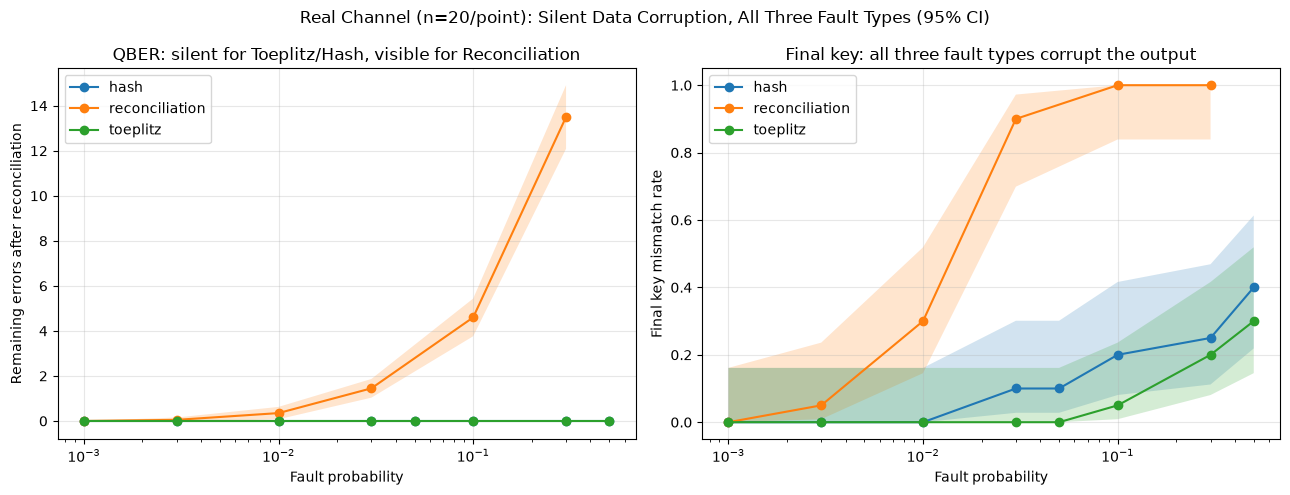

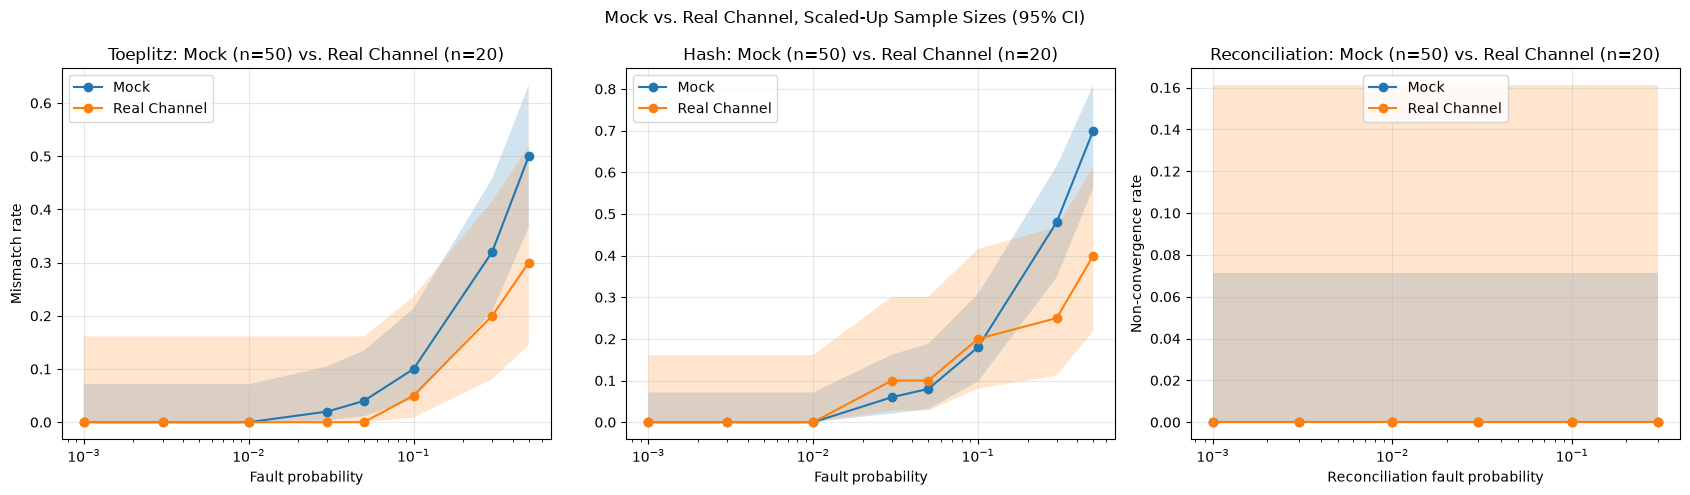

Both figures saved with scaled-up sample sizes.


In [15]:
"""
Recomputed plots using the new, larger-n data:
- sdc_mock_doseresponse_n50.csv (n=50 per point)
- sdc_realchannel_toeplitz_n20.csv, sdc_realchannel_hash_n20.csv,
  sdc_realchannel_reconciliation_n20.csv (n=20 per point)
Same figure structure as before, now with tighter confidence intervals.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


def wilson_ci(successes, n, confidence=0.95):
    if n == 0:
        return 0.0, 0.0, 0.0
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    half_width = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
    return p_hat, max(0, center - half_width), min(1, center + half_width)


def mean_ci(values, confidence=0.95):
    vals = values.dropna()
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = vals.mean()
    if n > 1:
        sem = vals.std(ddof=1) / np.sqrt(n)
        half_width = stats.t.ppf(1 - (1 - confidence) / 2, df=n - 1) * sem
    else:
        half_width = 0
    return mean, mean - half_width, mean + half_width


def rate_by_prob(df, prob_col, success_col):
    probs = sorted(df[prob_col].unique())
    rates, lo, hi = [], [], []
    for p in probs:
        sub = df[df[prob_col] == p]
        n = len(sub)
        successes = sub[success_col].fillna(False).astype(bool).sum()
        rate, rlo, rhi = wilson_ci(successes, n)
        rates.append(rate); lo.append(rlo); hi.append(rhi)
    return probs, rates, lo, hi


# ============================================================
# Load the new, larger-n data
# ============================================================
df_mock = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_mock_doseresponse_n50.csv"))
df_mock["mismatch"] = ~df_mock["keys_match"].fillna(False)

df_rc_toeplitz = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_toeplitz_n20.csv"))
df_rc_hash = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_hash_n20.csv"))
df_rc_recon = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_realchannel_reconciliation_n20.csv"))

df_rc_toeplitz["mismatch"] = ~df_rc_toeplitz["keys_match"].fillna(False)
df_rc_hash["mismatch"] = ~df_rc_hash["keys_match"].fillna(False)
df_rc_recon["mismatch"] = df_rc_recon["remaining_errors_after_reconciliation"].fillna(0) > 0

df_realchannel = pd.concat([df_rc_toeplitz, df_rc_hash], ignore_index=True)
df_realchannel_all = pd.concat([df_rc_toeplitz, df_rc_hash, df_rc_recon], ignore_index=True)


# ============================================================
# (a) 2-panel: QBER + mismatch, Real Channel, all 3 fault types (n=20)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

for fault_type, group_df in df_realchannel_all.groupby("fault_type"):
    probs = sorted(group_df["prob"].unique())
    qber_means, qber_lo, qber_hi = [], [], []
    mm_rates, mm_lo, mm_hi = [], [], []
    for p in probs:
        sub = group_df[group_df["prob"] == p]
        m, lo, hi = mean_ci(sub["remaining_errors_after_reconciliation"])
        qber_means.append(m); qber_lo.append(lo); qber_hi.append(hi)
        n = len(sub)
        rate, rlo, rhi = wilson_ci(sub["mismatch"].sum(), n)
        mm_rates.append(rate); mm_lo.append(rlo); mm_hi.append(rhi)

    ax1.plot(probs, qber_means, marker='o', label=fault_type)
    ax1.fill_between(probs, qber_lo, qber_hi, alpha=0.2)
    ax2.plot(probs, mm_rates, marker='o', label=fault_type)
    ax2.fill_between(probs, mm_lo, mm_hi, alpha=0.2)

ax1.set_xscale('log'); ax1.set_xlabel('Fault probability')
ax1.set_ylabel('Remaining errors after reconciliation')
ax1.set_title('QBER: silent for Toeplitz/Hash, visible for Reconciliation')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_xscale('log'); ax2.set_xlabel('Fault probability')
ax2.set_ylabel('Final key mismatch rate')
ax2.set_title('Final key: all three fault types corrupt the output')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Real Channel (n=20/point): Silent Data Corruption, All Three Fault Types (95% CI)')
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_a_qber_mismatch_realchannel_n20.png"), dpi=150)
plt.show()


# ============================================================
# (b) 3 panels: Toeplitz (Mock vs RC) | Hash (Mock vs RC) | Reconciliation (Mock vs RC)
# ============================================================
df_toeplitz_compare = pd.concat([
    df_mock[df_mock["fault_type"] == "toeplitz"].assign(channel="Mock"),
    df_rc_toeplitz.assign(channel="Real Channel"),
], ignore_index=True)

df_hash_compare = pd.concat([
    df_mock[df_mock["fault_type"] == "hash"].assign(channel="Mock"),
    df_rc_hash.assign(channel="Real Channel"),
], ignore_index=True)

df_recon_compare = pd.concat([
    df_mock[df_mock["fault_type"] == "reconciliation"].assign(channel="Mock"),
    df_rc_recon.assign(channel="Real Channel"),
], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for channel, group_df in df_toeplitz_compare.groupby("channel"):
    probs, rates, lo, hi = rate_by_prob(group_df, "prob", "mismatch")
    axes[0].plot(probs, rates, marker='o', label=channel)
    axes[0].fill_between(probs, lo, hi, alpha=0.2)
axes[0].set_xscale('log'); axes[0].set_xlabel('Fault probability')
axes[0].set_ylabel('Mismatch rate')
axes[0].set_title('Toeplitz: Mock (n=50) vs. Real Channel (n=20)')
axes[0].legend(); axes[0].grid(alpha=0.3)

for channel, group_df in df_hash_compare.groupby("channel"):
    probs, rates, lo, hi = rate_by_prob(group_df, "prob", "mismatch")
    axes[1].plot(probs, rates, marker='o', label=channel)
    axes[1].fill_between(probs, lo, hi, alpha=0.2)
axes[1].set_xscale('log'); axes[1].set_xlabel('Fault probability')
axes[1].set_title('Hash: Mock (n=50) vs. Real Channel (n=20)')
axes[1].legend(); axes[1].grid(alpha=0.3)

for channel, group_df in df_recon_compare.groupby("channel"):
    if channel == "Mock":
        probs, rates, lo, hi = rate_by_prob(group_df, "prob", "non_convergent")
    else:
        probs, rates, lo, hi = rate_by_prob(group_df, "prob", "non_convergent")
    axes[2].plot(probs, rates, marker='o', label=channel)
    axes[2].fill_between(probs, lo, hi, alpha=0.2)
axes[2].set_xscale('log'); axes[2].set_xlabel('Reconciliation fault probability')
axes[2].set_ylabel('Non-convergence rate')
axes[2].set_title('Reconciliation: Mock (n=50) vs. Real Channel (n=20)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Mock vs. Real Channel, Scaled-Up Sample Sizes (95% CI)')
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_b_mock_vs_realchannel_scaledup.png"), dpi=150)
plt.show()

print("Both figures saved with scaled-up sample sizes.")